# 京都红叶日期与秋季天气驱动因素的实证分析（2010—2025）

本研究使用日本气象厅官方物候资料与京都站日别天气数据，检验 2010—2025 年京都枫叶红叶日期与秋季天气条件之间的经验关系。第一版结论显示 11 月气温是核心信号；本版在同一官方数据源内继续扩展夜间低温、昼夜温差、日照、降水和强风等维度，用于区分“官方红叶日推进”与“游客见顷窗口质量”。Notebook 采用 pandas 与 NumPy 进行数据整理和统计计算，并使用 Matplotlib 与 Seaborn 生成可复核图表。


## 0. 研究问题与分析框架

**研究问题：** 除了秋季均温之外，京都官方枫叶红叶日期是否还受到夜间低温、昼夜温差、日照、降水和强风等天气维度的系统性影响？这些维度对旅行日期选择和现场观赏质量有什么启示？

分析框架如下：

1. 数据来源与获取：使用日本气象厅官方物候资料与京都站日别天气。
2. 数据清洗：统一年份范围，处理缺测记录，构造红叶日期偏移量、核心气温指标与扩展天气驱动指标。
3. 统计分析：使用 pandas/NumPy 计算相关系数、线性斜率与解释度，并与脚本生成的 CSV 结果交叉校验。
4. 结果可视化：使用 Matplotlib/Seaborn 展示年度偏移、回归关系、指标排序和日别降温轨迹。
5. 结论：将统计证据转化为日期选择规则，并区分官方物候日期与寺社现场“见顷”窗口。


In [1]:
from pathlib import Path
from io import StringIO

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, SVG, display

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

SUMMARY = ROOT / "data" / "processed" / "kyoto_koyo_temperature_2010_2025_summary.csv"
DAILY = ROOT / "data" / "raw" / "kyoto_daily_temperature_oct_dec_2010_2025.csv"
CORRELATIONS = ROOT / "data" / "processed" / "correlation_results.csv"

sns.set_theme(style="whitegrid", context="notebook", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "svg.fonttype": "none",
})

summary = pd.read_csv(SUMMARY)
daily = pd.read_csv(DAILY, parse_dates=["date"])
stored_corr = pd.read_csv(CORRELATIONS)

print(f"numpy={np.__version__}, pandas={pd.__version__}, matplotlib={matplotlib.__version__}, seaborn={sns.__version__}")
print(f"annual summary: {len(summary)} rows; daily weather: {len(daily)} rows; stored correlations: {len(stored_corr)} rows")

numpy=2.4.6, pandas=3.0.3, matplotlib=3.10.9, seaborn=0.13.2
annual summary: 16 rows; daily weather: 1472 rows; stored correlations: 29 rows


## 1. 数据来源与获取

红叶日期采用日本气象厅生物季节观测累年值中的京都 `かえでの紅葉日`。天气条件采用日本气象厅过去天气数据中的京都站日别值，包括气温、降水、湿度、风速、日照时间和天气概况。

数据源链接：

- 生物季节观测累年值（かえで紅葉）：https://www.data.jma.go.jp/sakura/data/ruinenchi/015.csv
- 京都站日别天气值：https://www.data.jma.go.jp/stats/etrn/view/daily_s1.php?prec_no=61&block_no=47759&year=YYYY&month=MM&day=&view=p1

为保证 Notebook 打开时具有稳定的可复现性，以下代码默认读取仓库中已经归档的 CSV 文件。如需刷新至气象厅最新数据，可在仓库根目录运行 `python3 scripts/fetch_and_analyze.py`，或将下方 `RUN_LIVE_FETCH` 改为 `True` 后执行。


In [2]:
PHENOLOGY_URL = "https://www.data.jma.go.jp/sakura/data/ruinenchi/015.csv"
WEATHER_URL_TEMPLATE = "https://www.data.jma.go.jp/stats/etrn/view/daily_s1.php?prec_no=61&block_no=47759&year=YYYY&month=MM&day=&view=p1"
RUN_LIVE_FETCH = False

print("红叶日数据源:", PHENOLOGY_URL)
print("天气数据源模板:", WEATHER_URL_TEMPLATE)
print("默认读取仓库中的已生成 CSV；如需刷新至气象厅最新数据，可将 RUN_LIVE_FETCH 改为 True 后执行。")

if RUN_LIVE_FETCH:
    import importlib.util
    spec = importlib.util.spec_from_file_location("fetch_and_analyze", ROOT / "scripts" / "fetch_and_analyze.py")
    analysis_module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(analysis_module)
    analysis_module.main()
    summary = pd.read_csv(SUMMARY)
    daily = pd.read_csv(DAILY, parse_dates=["date"])
    stored_corr = pd.read_csv(CORRELATIONS)


红叶日数据源: https://www.data.jma.go.jp/sakura/data/ruinenchi/015.csv
天气数据源模板: https://www.data.jma.go.jp/stats/etrn/view/daily_s1.php?prec_no=61&block_no=47759&year=YYYY&month=MM&day=&view=p1
默认读取仓库中的已生成 CSV；如需刷新至气象厅最新数据，可将 RUN_LIVE_FETCH 改为 True 后执行。


## 2. 数据清洗与变量构造

清洗后的核心变量如下：

- `red_date`：官方红叶日期；2021 年官方值为 `0`，转为缺测。
- `delay_vs_dec5_days`：相对平年日 12/5 的偏移；正数表示偏晚，负数表示偏早。
- 温度推进指标：`oct_mean_c`、`nov_mean_c`、`oct_nov_mean_c`、`nov_dec10_days_le_10c`。
- 夜间低温指标：`nov_min_mean_c`、`nov_min_days_le_8c`、`first_min_le_8`（从 11 月 1 日起搜索）。
- 观赏质量与窗口稳定性指标：`nov_diurnal_range_mean_c`、`nov_sunshine_hours_total`、`nov_precip_total_mm`、`rain_days_nov`（≥1 mm）、`heavy_rain_days_after_nov15`（≥20 mm）、`max_gust_nov_dec10_ms`、`windy_days_after_nov15`（最大瞬间风速 ≥10 m/s）。

**表 1：年度观测与天气指标**

**阅读方法：** 按年份逐行阅读。`official red date` 是该年京都官方枫叶红叶日期；`delay vs Dec 5 (d)` 是相对平年日 12 月 5 日的偏移，正值表示偏晚，负值表示偏早；后续列给出 11 月均温、11 月最低温均值、11/1—12/10 冷日数量、11 月日照、11 月降水和 11/1—12/10 最大瞬间风速。

**表格说明：** 该表把研究的因变量和第一阶段扩展天气解释变量放在同一年度面板中。它保留 11 月气温这一核心信号，同时加入夜间低温、日照、降水和风力等更贴近红叶推进与现场观赏质量的维度。2021 年红叶日期缺测但天气指标仍可保留；2024 年红叶日期相对 12 月 5 日晚 15 天，是样本期内最晚年份。


In [3]:
summary = summary.copy()
daily = daily.copy()

summary["red_date"] = pd.to_datetime(summary["red_date"], errors="coerce")
summary["delay_vs_dec5_days"] = pd.to_numeric(summary["delay_vs_dec5_days"], errors="coerce")
summary_numeric_columns = [
    "oct_mean_c", "nov_mean_c", "dec_mean_c", "oct_nov_mean_c", "nov_dec10_mean_c", "nov16_dec10_mean_c",
    "nov_min_mean_c", "nov_dec10_min_mean_c", "nov_min_days_le_8c", "nov_min_days_le_5c",
    "first_min_le_8_day_from_oct1", "nov_diurnal_range_mean_c", "nov_dec10_diurnal_range_mean_c",
    "nov_days_range_ge_10c", "nov_sunshine_hours_total", "nov_dec10_sunshine_hours_total",
    "sunny_cold_nights_nov_dec10", "oct_nov_precip_total_mm", "nov_precip_total_mm", "rain_days_nov",
    "heavy_rain_days_after_nov15", "max_gust_nov_dec10_ms", "windy_days_after_nov15",
    "nov_days_le_10c", "nov_days_le_12c", "nov_dec10_days_le_10c", "nov_dec10_days_le_12c",
]
for column in summary_numeric_columns:
    summary[column] = pd.to_numeric(summary[column], errors="coerce")

daily_numeric_columns = [
    "precip_total_mm", "t_mean_c", "t_max_c", "t_min_c", "humidity_mean_pct", "humidity_min_pct",
    "wind_mean_ms", "wind_max_ms", "gust_max_ms", "sunshine_hours",
]
for column in daily_numeric_columns:
    daily[column] = pd.to_numeric(daily[column], errors="coerce")

valid = summary.dropna(subset=["delay_vs_dec5_days"]).copy()
annual_view = summary.assign(
    red_md=summary["red_date"].dt.strftime("%m/%d").fillna("缺测"),
    delay=lambda df: df["delay_vs_dec5_days"].map(lambda x: "" if pd.isna(x) else f"{x:+.0f}"),
)[[
    "year", "red_md", "delay", "nov_mean_c", "nov_min_mean_c", "nov_dec10_days_le_10c",
    "nov_sunshine_hours_total", "nov_precip_total_mm", "max_gust_nov_dec10_ms",
]]
annual_view = annual_view.rename(columns={
    "year": "year",
    "red_md": "official red date",
    "delay": "delay vs Dec 5 (d)",
    "nov_mean_c": "Nov mean °C",
    "nov_min_mean_c": "Nov min mean °C",
    "nov_dec10_days_le_10c": "Nov 1-Dec 10 <=10°C days",
    "nov_sunshine_hours_total": "Nov sunshine h",
    "nov_precip_total_mm": "Nov precip mm",
    "max_gust_nov_dec10_ms": "Max gust Nov1-Dec10 m/s",
}).round(2)
display(HTML(annual_view.to_html(index=False, border=0)))


year,official red date,delay vs Dec 5 (d),Nov mean °C,Nov min mean °C,Nov 1-Dec 10 <=10°C days,Nov sunshine h,Nov precip mm,Max gust Nov1-Dec10 m/s
2010,12/13,+8,11.75,7.28,13,145.2,15.0,20.4
2011,12/14,+9,13.79,9.87,11,119.8,73.0,13.7
2012,12/07,+2,11.14,7.54,20,119.8,120.0,14.5
2013,12/05,+0,11.51,7.35,22,162.2,50.0,16.3
2014,12/09,+4,13.15,9.31,13,139.6,60.0,13.7
2015,12/14,+9,14.45,11.15,11,116.8,177.0,14.3
2016,12/06,+1,12.49,8.79,12,131.4,82.0,14.6
2017,12/01,-4,11.20,7.11,21,158.0,43.0,14.9
2018,12/12,+7,13.49,9.49,5,143.9,22.5,11.9
2019,12/10,+5,12.92,8.85,14,181.1,25.5,14.3


### 2.1 缺测处理与覆盖检查

2021 年京都 `かえでの紅葉` 在气象厅累年 CSV 中记录为 `0`。该值不能解释为有效日期，因此在涉及红叶日期的相关性计算中按缺测处理；同期气温记录仍保留在原始与汇总数据中。

**表 2：日别天气覆盖检查**

**阅读方法：** 按月份阅读 `expected_days`、`min_observed_days` 与 `max_observed_days`。若最小观测天数和最大观测天数均等于该月应有天数，说明所有年份在该月的日别天气记录完整，没有因缺日造成的月度指标偏差。

**表格说明：** 该表验证 2010—2025 年每个年份的 10 月、11 月、12 月日别天气覆盖均完整。它反映出后续月均温、冷日数、日照、降水和风力指标不是由不均衡观测天数造成的伪差异，而是来自完整的日别天气序列。

**表 3：缺测处理规则**

**阅读方法：** 按 `item` 阅读每类数据对象，再看 `rule` 中对应的处理规则。重点区分红叶日期缺测和气温记录保留：红叶日期缺测会影响相关性样本量，气温记录保留则保证年度气温描述仍完整。

**表格说明：** 该表明确研究的缺测口径。它反映出样本量从 16 个年份降为 15 个有效红叶观测值的原因只来自 2021 年官方红叶日期缺测，而不是气象数据缺失。该规则避免把气象厅的 `0` 误读成实际日期。


In [4]:
coverage = daily.groupby(["year", "month"]).size().unstack("month")
coverage_summary = pd.DataFrame({
    "month": ["October", "November", "December"],
    "expected_days": [31, 30, 31],
    "min_observed_days": [int(coverage[10].min()), int(coverage[11].min()), int(coverage[12].min())],
    "max_observed_days": [int(coverage[10].max()), int(coverage[11].max()), int(coverage[12].max())],
})
missing_policy = pd.DataFrame([
    {"item": "official red-leaf date", "rule": "2021 value is 0 in JMA CSV; treated as missing"},
    {"item": "temperature records", "rule": "all 2010-2025 October-December daily rows retained"},
    {"item": "correlation sample", "rule": "15 valid annual red-leaf observations"},
])
display(HTML(coverage_summary.to_html(index=False, border=0)))
display(HTML(missing_policy.to_html(index=False, border=0)))

month,expected_days,min_observed_days,max_observed_days
October,31,31,31
November,30,30,30
December,31,31,31


item,rule
official red-leaf date,2021 value is 0 in JMA CSV; treated as missing
temperature records,all 2010-2025 October-December daily rows retained
correlation sample,15 valid annual red-leaf observations


## 3. 统计分析

因变量为 `delay_vs_dec5_days`。候选解释变量包括 10 月均温、11 月均温、10—11 月均温、11/1—12/10 均温、冷日数量、夜间最低温、昼夜温差、日照、降水和强风代理指标。下表列出主要指标与红叶日期偏移量之间的相关性和线性斜率。

**表 4：天气指标与红叶延迟的统计关系**

**阅读方法：** 先看 `Pearson r` 的正负和绝对值，正值表示指标越高红叶越晚，负值表示指标越高红叶越早；再看 `slope days/unit`，它表示该指标每增加 1 个单位时，红叶日期相对 12 月 5 日平均变化多少天；最后看 `R²`，用于判断单变量线性关系的解释度。

**表格说明：** 该表反映出 11 月均温和 10—11 月均温仍是解释官方红叶日推迟的核心指标。扩展天气维度用于补充解释：夜间低温和冷日数更接近红叶推进机制，日照、降水和强风则更偏向解释游客见顷窗口的质量与稳定性。由于有效年份只有 15 个，本研究只做单变量探索，不把这些维度强行塞入多元预测模型。


In [5]:
metric_labels = {
    "oct_nov_mean_c": "Oct-Nov mean",
    "nov_mean_c": "November mean",
    "nov_dec10_mean_c": "Nov 1-Dec 10 mean",
    "nov16_dec10_mean_c": "Nov 16-Dec 10 mean",
    "dec_mean_c": "December mean",
    "oct_mean_c": "October mean",
    "nov_min_mean_c": "November min mean",
    "nov_dec10_min_mean_c": "Nov 1-Dec 10 min mean",
    "nov_min_days_le_8c": "Nov min <=8°C days",
    "first_min_le_8_day_from_oct1": "First min <=8°C day",
    "nov_diurnal_range_mean_c": "Nov day-night range",
    "nov_sunshine_hours_total": "Nov sunshine hours",
    "sunny_cold_nights_nov_dec10": "Sunny cold nights",
    "nov_precip_total_mm": "Nov precipitation",
    "heavy_rain_days_after_nov15": "Heavy rain days after Nov 15",
    "max_gust_nov_dec10_ms": "Max gust Nov 1-Dec 10",
    "nov_dec10_days_le_10c": "Cold days <=10°C",
    "nov_dec10_days_le_12c": "Cool days <=12°C",
}
metric_order = [
    "oct_nov_mean_c",
    "nov_mean_c",
    "nov_dec10_mean_c",
    "nov16_dec10_mean_c",
    "nov_min_mean_c",
    "nov_dec10_min_mean_c",
    "nov_min_days_le_8c",
    "first_min_le_8_day_from_oct1",
    "nov_dec10_days_le_10c",
    "nov_dec10_days_le_12c",
    "nov_diurnal_range_mean_c",
    "nov_sunshine_hours_total",
    "sunny_cold_nights_nov_dec10",
    "nov_precip_total_mm",
    "heavy_rain_days_after_nov15",
    "max_gust_nov_dec10_ms",
    "dec_mean_c",
    "oct_mean_c",
]

analysis_rows = []
for metric in metric_order:
    data = summary[[metric, "delay_vs_dec5_days"]].dropna()
    x = data[metric].to_numpy(dtype=float)
    y = data["delay_vs_dec5_days"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    analysis_rows.append({
        "metric": metric,
        "label": metric_labels[metric],
        "n": int(len(data)),
        "pearson_r": float(data[metric].corr(data["delay_vs_dec5_days"], method="pearson")),
        "spearman_r": float(data[metric].rank().corr(data["delay_vs_dec5_days"].rank(), method="pearson")),
        "slope_days_per_unit": float(slope),
        "intercept_days": float(intercept),
        "r2": 1 - ss_res / ss_tot,
    })
analysis = pd.DataFrame(analysis_rows).sort_values("pearson_r", key=lambda s: s.abs(), ascending=False)

stored = stored_corr.set_index("metric")
for _, row in analysis.iterrows():
    metric = row["metric"]
    assert np.isclose(row["pearson_r"], stored.loc[metric, "pearson_r"], atol=1e-6)
    assert np.isclose(row["slope_days_per_unit"], stored.loc[metric, "slope_days_per_unit"], atol=1e-6)

analysis_display = analysis[["label", "n", "pearson_r", "spearman_r", "slope_days_per_unit", "r2"]].copy()
analysis_display.columns = ["metric", "n", "Pearson r", "Spearman r", "slope days/unit", "R²"]
display(HTML(analysis_display.round({"Pearson r": 3, "Spearman r": 3, "slope days/unit": 2, "R²": 3}).to_html(index=False, border=0)))


metric,n,Pearson r,Spearman r,slope days/unit,R²
Oct-Nov mean,15,0.729,0.472,4.37,0.531
November mean,15,0.714,0.719,2.98,0.509
Nov 1-Dec 10 mean,15,0.709,0.707,3.01,0.503
Nov 1-Dec 10 min mean,15,0.682,0.660,2.73,0.466
November min mean,15,0.672,0.680,2.59,0.452
Cold days <=10°C,15,-0.644,-0.576,-0.65,0.415
Cool days <=12°C,15,-0.517,-0.478,-0.45,0.268
Nov 16-Dec 10 mean,15,0.504,0.423,1.88,0.254
December mean,15,0.393,0.423,1.55,0.155
Heavy rain days after Nov 15,15,0.369,0.443,2.42,0.136


## 4. 结果可视化

以下图表展示四个互补视角：年度偏移、11 月均温回归、指标相关性排序，以及 10—12 月日别降温轨迹。


In [6]:
def display_figure(fig):
    """Render a Matplotlib figure as SVG so GitHub and Jupyter show crisp vector graphics."""
    buffer = StringIO()
    fig.savefig(buffer, format="svg", bbox_inches="tight")
    plt.close(fig)
    display(SVG(buffer.getvalue()))

### 图 1：年度红叶偏移与 11 月均温

**阅读方法：** 左轴柱状条表示官方红叶日期相对 12 月 5 日的偏移，正值表示偏晚，负值表示偏早；右轴折线表示同年 11 月均温。阅读时应同时比较柱状条高度和折线位置，观察偏晚年份是否伴随较高的 11 月均温。

**图表说明：** 该图反映年度层面的时间序列关系：2024 年是样本期内最晚记录，并伴随较高的 11 月均温；2025 年仍偏晚，但偏移幅度明显小于 2024 年。该图说明红叶季判断不能只看年份顺序或个别异常点，需要把官方红叶日期与 11 月降温背景共同解读。


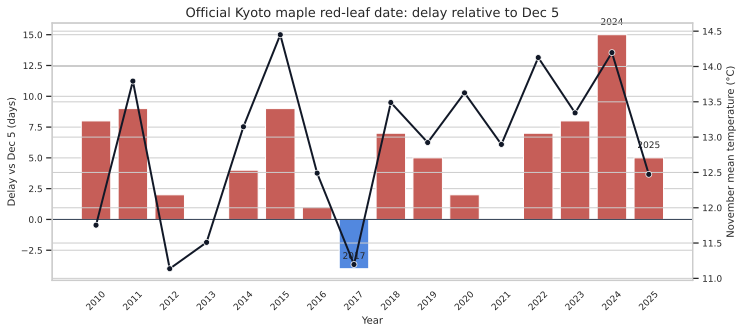

In [7]:
fig, ax1 = plt.subplots(figsize=(10.5, 4.8))
plot_df = summary.copy()
colors = np.where(plot_df["delay_vs_dec5_days"].fillna(0) >= 0, "#d94d45", "#3b82f6")
sns.barplot(data=plot_df, x="year", y="delay_vs_dec5_days", ax=ax1, palette=list(colors), hue="year", legend=False)
ax1.axhline(0, color="#334155", linewidth=1)
ax1.set_title("Official Kyoto maple red-leaf date: delay relative to Dec 5")
ax1.set_xlabel("Year")
ax1.set_ylabel("Delay vs Dec 5 (days)")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
sns.lineplot(data=plot_df, x=np.arange(len(plot_df)), y="nov_mean_c", ax=ax2, color="#111827", marker="o", linewidth=2)
ax2.set_ylabel("November mean temperature (°C)")
for _, row in plot_df[plot_df["year"].isin([2017, 2024, 2025])].iterrows():
    if pd.notna(row["delay_vs_dec5_days"]):
        ax1.text(int(row["year"]) - int(plot_df["year"].min()), row["delay_vs_dec5_days"] + 0.8, str(int(row["year"])), ha="center", fontsize=9)
fig.tight_layout()
display_figure(fig)

### 图 2：11 月均温与红叶延迟的回归关系

**阅读方法：** 横轴为 11 月均温，纵轴为相对 12 月 5 日的红叶延迟天数。每个点代表一个有效年份；红色回归线表示线性趋势，灰色带表示趋势估计的不确定区间。点越靠右表示 11 月越暖，点越靠上表示红叶越晚。

**图表说明：** 该图反映出 11 月偏暖与红叶推迟之间存在明显正相关，且斜率约为每 +1°C 推迟 3 天。它是旅行日期推论中最直接的证据：如果某年 11 月持续偏暖，应将核心赏枫窗口向 12 月上旬后段移动；若 11 月降温充分，则不应仅凭 10 月偏暖判断红叶会大幅推迟。


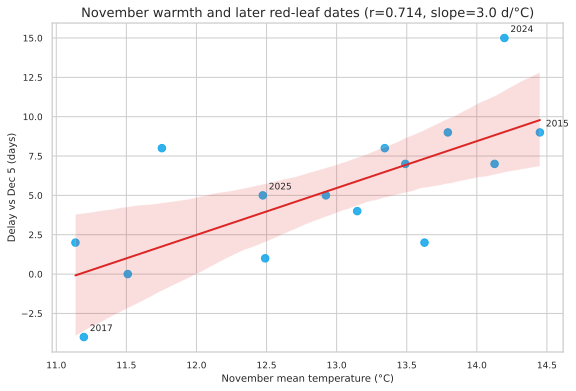

In [8]:
fig, ax = plt.subplots(figsize=(8.2, 5.6))
sns.regplot(
    data=valid,
    x="nov_mean_c",
    y="delay_vs_dec5_days",
    ax=ax,
    ci=95,
    scatter_kws={"s": 58, "alpha": 0.85, "color": "#0ea5e9"},
    line_kws={"color": "#dc2626", "linewidth": 2},
)
for _, row in valid[valid["year"].isin([2015, 2017, 2024, 2025])].iterrows():
    ax.annotate(str(int(row["year"])), (row["nov_mean_c"], row["delay_vs_dec5_days"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
nov = analysis.set_index("metric").loc["nov_mean_c"]
ax.set_title(f"November warmth and later red-leaf dates (r={nov.pearson_r:.3f}, slope={nov.slope_days_per_unit:.1f} d/°C)")
ax.set_xlabel("November mean temperature (°C)")
ax.set_ylabel("Delay vs Dec 5 (days)")
fig.tight_layout()
display_figure(fig)

### 图 3：天气指标相关性排序

**阅读方法：** 横轴为 Pearson 相关系数，条形越向右表示该指标越高时红叶越晚，越向左表示该指标越高时红叶越早；条形长度表示线性相关强度。阅读时重点比较不同指标的绝对值，而不是只看正负方向。

**图表说明：** 该图反映各天气指标的解释力排序：10—11 月均温和 11 月均温仍位于正相关较强的一侧，说明持续偏暖比单个 10 月信号更有解释力；≤10°C 冷日数与部分夜间低温指标位于负相关一侧，说明低温积累对红叶推进有相反方向的影响。日照、降水和强风指标应谨慎解释，它们更像观赏质量和窗口稳定性的补充信号，而不是官方日期的单独预测器。


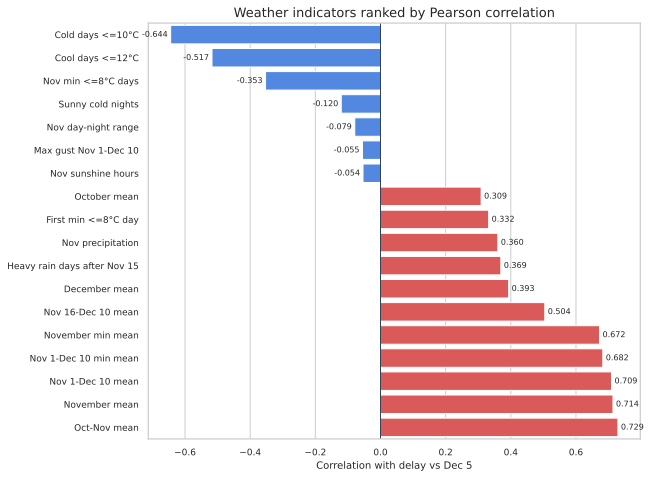

In [9]:
fig, ax = plt.subplots(figsize=(9.2, 6.8))
bar_df = analysis_display.copy().sort_values("Pearson r")
palette = ["#3b82f6" if value < 0 else "#ef4444" for value in bar_df["Pearson r"]]
sns.barplot(data=bar_df, x="Pearson r", y="metric", ax=ax, palette=palette, hue="metric", legend=False)
ax.axvline(0, color="#334155", linewidth=1)
ax.set_title("Weather indicators ranked by Pearson correlation")
ax.set_xlabel("Correlation with delay vs Dec 5")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
fig.tight_layout()
display_figure(fig)


### 图 4：10—12 月日别降温轨迹

**阅读方法：** 纵轴为年份，横轴为从 10 月 1 日开始的季节日序；颜色表示日均温，暖色代表较高温，冷色代表较低温。阅读时应观察每年从 11 月进入 12 月的颜色转换速度，尤其关注 11 月后半段至 12 月上旬是否持续转冷。

**图表说明：** 该图反映日尺度降温过程，而不是单一月均温。它显示不同年份进入低温状态的时间并不一致，解释了为什么红叶日期可能在相似 10 月均温下表现不同。对于旅行决策，热力图提示应重点跟踪 11 月后的连续降温，而非把 10 月偏暖直接等同于整季偏晚。


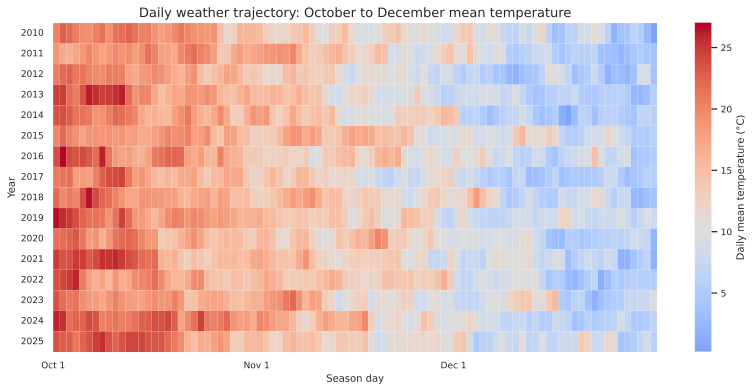

In [10]:
heat = daily[daily["month"].isin([10, 11, 12])].copy()
heat["season_day"] = (heat["date"] - pd.to_datetime(heat["year"].astype(str) + "-10-01")).dt.days + 1
heat_pivot = heat.pivot_table(index="year", columns="season_day", values="t_mean_c", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11.5, 5.6))
sns.heatmap(heat_pivot, ax=ax, cmap="coolwarm", center=10, cbar_kws={"label": "Daily mean temperature (°C)"})
month_ticks = [1, 32, 62]
month_labels = ["Oct 1", "Nov 1", "Dec 1"]
ax.set_xticks([tick - 1 for tick in month_ticks])
ax.set_xticklabels(month_labels, rotation=0)
ax.set_title("Daily weather trajectory: October to December mean temperature")
ax.set_xlabel("Season day")
ax.set_ylabel("Year")
fig.tight_layout()
display_figure(fig)

## 5. 结论与日期选择推论

统计结果支持以下判断：

- **常规年份：** 核心赏枫窗口可设为 11月28日—12月10日。
- **11 月显著偏暖：** 窗口应后移至 12月3日—12月14日。
- **11 月明显偏冷：** 窗口可提前至 11月22日—12月5日。
- **10 月偏暖但 11 月转冷：** 不宜仅凭 10 月气温判定红叶将显著推迟；2025 年属于这一类型。
- **10 月与 11 月均持续偏暖：** 需关注类似 2024 年的大幅推迟风险。

扩展天气维度的解释边界如下：

- **官方红叶日推进信号：** 11 月均温、11/1—12/10 冷日数、夜间最低温和第一次稳定低温日期更接近物候推进机制。
- **游客见顷质量信号：** 日照、昼夜温差、强降水和强风更偏向解释颜色鲜艳度、落叶速度和现场窗口稳定性。
- **不做过度预测：** 有效年份只有 15 个，扩展维度用于探索与解释残差，不应被包装成精确的多元机器学习预测。

上述推论使用的是京都官方物候日期，而非任一寺社的现场“见顷”日期。高雄、大原、贵船、鞍马等北部或高海拔区域通常早于市区；清水寺、东福寺、下鸭神社等低海拔或市区点位可能更晚。


In [11]:
analysis_by_metric = analysis.set_index("metric")
nov = analysis_by_metric.loc["nov_mean_c"]
oct_nov = analysis_by_metric.loc["oct_nov_mean_c"]
cold = analysis_by_metric.loc["nov_dec10_days_le_10c"]
night_min = analysis_by_metric.loc["nov_min_mean_c"]
sunshine = analysis_by_metric.loc["nov_sunshine_hours_total"]
gust = analysis_by_metric.loc["max_gust_nov_dec10_ms"]
print("研究结论:")
print(f"1. 11 月均温与官方红叶日期偏晚的相关性较强：Pearson r={nov.pearson_r:.3f}，斜率约 {nov.slope_days_per_unit:.1f} 天/°C。")
print(f"2. 10—11 月整体均温解释力最高：Pearson r={oct_nov.pearson_r:.3f}，斜率约 {oct_nov.slope_days_per_unit:.1f} 天/°C。")
print(f"3. 11/1—12/10 的 ≤10°C 冷日数与红叶延迟负相关：Pearson r={cold.pearson_r:.3f}。")
print(f"4. 夜间最低温也是值得继续跟踪的候选信号：11 月平均最低温 Pearson r={night_min.pearson_r:.3f}。")
print(f"5. 日照和强风指标更适合解释游客见顷质量：11 月日照 Pearson r={sunshine.pearson_r:.3f}，11/1—12/10 最大瞬间风速 Pearson r={gust.pearson_r:.3f}。")
print("6. 日期选择上，常规窗口为 11月28日—12月10日；若 11 月显著偏暖，可后移至 12月3日—12月14日。")


研究结论:
1. 11 月均温与官方红叶日期偏晚的相关性较强：Pearson r=0.714，斜率约 3.0 天/°C。
2. 10—11 月整体均温解释力最高：Pearson r=0.729，斜率约 4.4 天/°C。
3. 11/1—12/10 的 ≤10°C 冷日数与红叶延迟负相关：Pearson r=-0.644。
4. 夜间最低温也是值得继续跟踪的候选信号：11 月平均最低温 Pearson r=0.672。
5. 日照和强风指标更适合解释游客见顷质量：11 月日照 Pearson r=-0.054，11/1—12/10 最大瞬间风速 Pearson r=-0.055。
6. 日期选择上，常规窗口为 11月28日—12月10日；若 11 月显著偏暖，可后移至 12月3日—12月14日。
